# Plane Boarding Simulator Demo

This notebook demonstrates how to:

1. Import and configure the plane boarding simulator
2. Run a single simulation for one boarding strategy
3. Compare multiple strategies using total boarding time
4. (Optional) View congestion over time
5. (Optional) Display an animated GIF of the boarding process


In [14]:
import os
import sys
import statistics
import matplotlib.pyplot as plt
from utils import plot_boarding_metrics

from pathlib import Path

# Detect repo root (works whether notebook is opened from root or from examples/)
cwd = os.getcwd()
if os.path.basename(cwd) == "examples":
    repo_root = os.path.dirname(cwd)
else:
    repo_root = cwd

repo_root = Path(repo_root).resolve()
src_path = repo_root / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

print("Repo root:", repo_root)
print("Using src path:", src_path)

from simulation import SimConfig, run_once
from basic_strategies import back_to_front, steffen

Repo root: /home/manpazito/projects/plane-boarding-sim
Using src path: /home/manpazito/projects/plane-boarding-sim/src


## Running a Single Simulation


In [15]:
cfg = SimConfig()
cfg.num_rows = 30
cfg.num_passengers = 180
cfg.seed = 42  # for reproducibility

metrics, plane, passengers = run_once(
    cfg,
    boarding_strategy=steffen,
    animate=False,  # set True to print ASCII frames in the notebook output
    save_frames=True,  # saves frames under results/
    perfect_queue=True,  # deterministic ordering
    auto_make_gif=False,  # we will call the GIF function separately below if we want
)

print(f"Strategy: {steffen.name}")
print(f"Total ticks: {metrics.total_ticks}")
print(f"Passengers seated: {metrics.seated_count}")
print(f"Number of congestion samples: {len(metrics.congestion_ts)}")

Strategy: steffen
Total ticks: 641
Passengers seated: 180
Number of congestion samples: 641


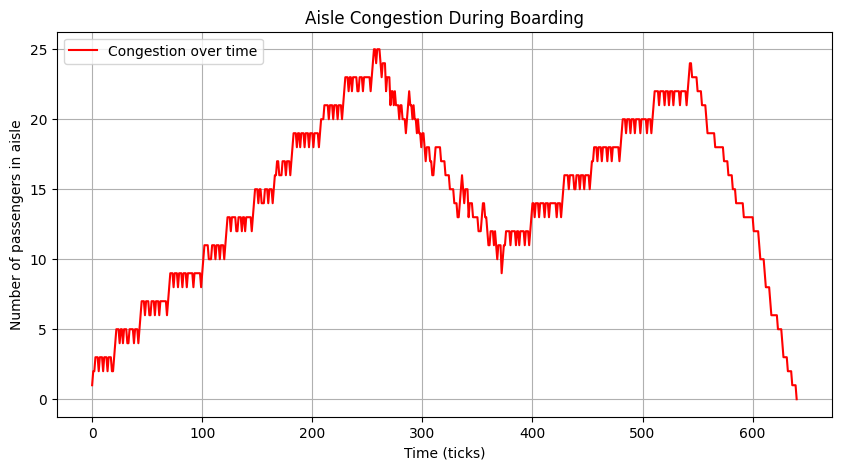

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(metrics.congestion_ts, label="Congestion over time", c="r")
plt.xlabel("Time (ticks)")
plt.ylabel("Number of passengers in aisle")
plt.title("Aisle Congestion During Boarding")
plt.legend()
plt.grid()
plt.show()

## Comparison of 2 Methods over 10 Runs


In [16]:
def run_many(strategy, n_runs=10, num_rows=30, num_passengers=180):
    totals = []
    for i in range(n_runs):
        cfg = SimConfig()
        cfg.num_rows = num_rows
        cfg.num_passengers = num_passengers
        cfg.seed = i  # different seed each run

        metrics, plane, passengers = run_once(
            cfg,
            boarding_strategy=strategy,
            animate=False,
            save_frames=False,
            perfect_queue=False,  # allow randomness in the queue
        )
        totals.append(metrics.total_ticks)
    return totals


strategies = {
    "back_to_front": back_to_front,
    "steffen": steffen,
}

results = {}
for name, strat in strategies.items():
    totals = run_many(strat, n_runs=10)
    results[name] = totals
    print(
        f"{name}: mean={statistics.mean(totals):.1f}, stdev={statistics.pstdev(totals):.1f}"
    )

back_to_front: mean=568.4, stdev=17.7
steffen: mean=641.0, stdev=29.0


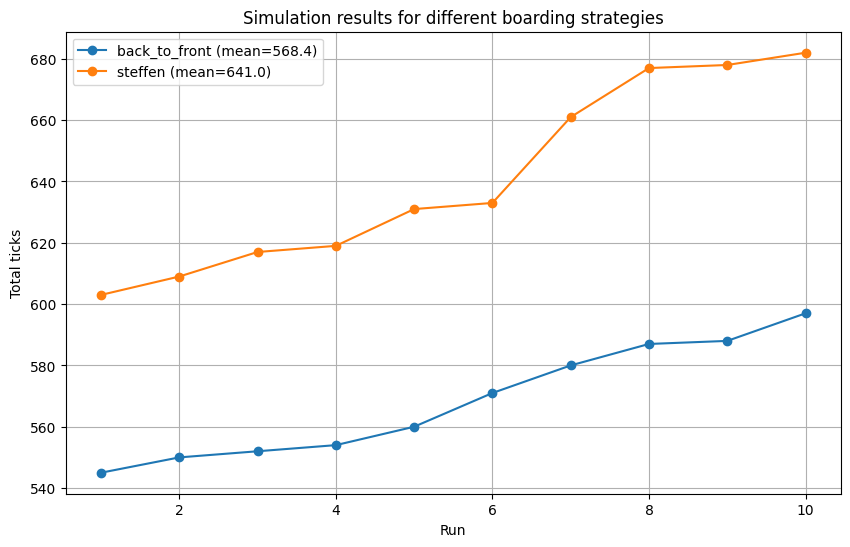

In [17]:
plt.figure(figsize=(10, 6))
for name, totals in results.items():
    plt.plot(
        range(1, len(totals) + 1),
        sorted(totals),
        marker="o",
        label=f"{name} (mean={statistics.mean(totals):.1f})",
    )
plt.xlabel("Run")
plt.ylabel("Total ticks")
plt.title("Simulation results for different boarding strategies")
plt.legend()
plt.grid(True)
plt.show()